# Fisher analysis of the per-MOSA TM noise amplitudes

Uses the basis covariances from `fisher_tm_basis.ipynb` (one week of mojito_lite, 1e-4 - 0.1 Hz) to find which
TM combinations the data constrain, to compare parametrizations, and to check against the 12-parameter STFT
chain (one week, equal injected noises). Notes: `scripts/notes/TM_PROXY_PARAMS.md`.

Parameters are log-amplitudes $\theta = (\ln a_m, \ln b_m)$, $m$ = 12, 23, 31, 13, 32, 21 (OMS, TM), with
$\partial C / \partial \ln b_m = 2 b_m^2 B_m$. Whittle Fisher matrix, one complex bin per frequency:
$F_{ij} = \sum_f \mathrm{Re}\,\mathrm{tr}(C^{-1}\partial_i C\, C^{-1}\partial_j C)$.

In [1]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
import corner

from lisatools.sensitivity import MOSA_NAMES, TM_PROXY_ARMS

np.set_printoptions(precision=3, suppress=True, linewidth=150)
FISHER_DIR = "/mnt/wd_hdd_6TB/nikos/DATA/global_fit/fisher_tm/"
WEEK = 0
CHAIN = ("/mnt/wd_hdd_6TB/nikos/DATA/global_fit/gf_output/unequal_noises_preproc-bias_inv_fmax:1.0e-01/"
         "unequal_noises_preproc-bias_inv_stft_parameter_estimation_main.h5")
BURN_FRAC = 0.5
N_WEEKS_FULL = 102      # ~714 days of mojito_lite after trimming
S_OMS, S_TM = 15e-12, 3e-15
ARMS = [(0, 5), (1, 4), (2, 3)]   # (clockwise, counter-clockwise) MOSA index per arm 12, 23, 31

z = np.load(f"{FISHER_DIR}basis_week{WEEK}.npz")
f, B_oms, B_tm, C_inj = z["f"], z["Boms"], z["Btm"], z["C"]
print("frequencies:", f.size, f[0], f[-1])

frequencies: 60420 0.00010085978835978836 0.1


## 1. Exact null direction

$\sum_{\rm cw} B^{\rm TM}_m = \sum_{\rm ccw} B^{\rm TM}_m$ (cw = 12, 23, 31; ccw = 13, 32, 21): shifting $P$ by $+t$ on
the clockwise and $-t$ on the counter-clockwise MOSAs leaves every covariance element unchanged.
The OMS basis has no such combination.

In [2]:
n_cw = np.array([1, 1, 1, -1, -1, -1.0])
for name, B in (("TM", B_tm), ("OMS", B_oms)):
    rel = np.max(np.abs(np.einsum("m,mabf->abf", n_cw, B)) / np.abs(B).sum(0))
    print(f"{name}: max |sum_cw B - sum_ccw B| / sum |B| = {rel:.1e}")

TM: max |sum_cw B - sum_ccw B| / sum |B| = 1.5e-14
OMS: max |sum_cw B - sum_ccw B| / sum |B| = 1.0e+00


## 2. Fisher matrix and TM eigen-directions (OMS marginalised)

In [3]:
D = np.concatenate([2 * S_OMS**2 * B_oms, 2 * S_TM**2 * B_tm])          # d C / d theta, (12, 3, 3, Nf)
A = np.einsum("fab,mbcf->mfac", np.linalg.inv(np.moveaxis(C_inj, -1, 0)), D)

def fisher(sel=slice(None)):
    return np.real(np.einsum("ifab,jfba->ij", A[:, sel], A[:, sel]))

def marginalise(F, keep):
    """Fisher of the `keep` block with the other parameters marginalised (Schur complement)."""
    drop = [i for i in range(F.shape[0]) if i not in keep]
    Fk, Fkd, Fd = F[np.ix_(keep, keep)], F[np.ix_(keep, drop)], F[np.ix_(drop, drop)]
    return Fk - Fkd @ np.linalg.pinv(Fd) @ Fkd.T

F = fisher()
TM, OMS = list(range(6, 12)), list(range(6))
for lo, hi in [(1e-4, 1e-1), (1e-4, 3e-3), (3e-3, 1e-1)]:
    sel = (f >= lo) & (f < hi)
    Fb = fisher(sel)
    lam, V = np.linalg.eigh(marginalise(Fb, TM))
    print(f"\n=== {lo:g} - {hi:g} Hz ({sel.sum()} bins) ===")
    print("OMS sigma(ln a), TM marginalised:", np.sqrt(np.diag(np.linalg.pinv(marginalise(Fb, OMS)))))
    print("TM eigen-directions in ln b, MOSAs", MOSA_NAMES)
    for l, v in sorted(zip(lam, V.T), key=lambda t: -t[0]):
        v = v * np.sign(v[np.argmax(np.abs(v))])
        print(f"  sigma = {1 / np.sqrt(l) if l > 1e-12 * lam.max() else np.inf:9.3e}   v = {v}")


=== 0.0001 - 0.1 Hz (60419 bins) ===
OMS sigma(ln a), TM marginalised: [0.005 0.005 0.005 0.005 0.005 0.005]
TM eigen-directions in ln b, MOSAs ['12', '23', '31', '13', '32', '21']
  sigma = 2.356e-02   v = [0.442 0.389 0.391 0.391 0.389 0.442]
  sigma = 3.417e-02   v = [ 0.551 -0.282 -0.342 -0.338 -0.286  0.551]
  sigma = 3.460e-02   v = [-0.032  0.518 -0.48  -0.482  0.516 -0.028]
  sigma = 2.393e-01   v = [ 0.554 -0.417 -0.137  0.133  0.42  -0.553]
  sigma = 2.395e-01   v = [ 0.162  0.399 -0.561  0.562 -0.396 -0.166]
  sigma =       inf   v = [-0.408 -0.408 -0.408  0.408  0.408  0.408]

=== 0.0001 - 0.003 Hz (1754 bins) ===
OMS sigma(ln a), TM marginalised: [0.503 0.503 0.503 0.503 0.503 0.503]
TM eigen-directions in ln b, MOSAs ['12', '23', '31', '13', '32', '21']
  sigma = 2.629e-02   v = [0.427 0.398 0.399 0.399 0.398 0.427]
  sigma = 5.543e-02   v = [ 0.563 -0.284 -0.32  -0.304 -0.3    0.564]
  sigma = 5.694e-02   v = [-0.021  0.511 -0.489 -0.499  0.501 -0.001]
  sigma = 3.223e-

## 3. Parametrizations

Every parametrization is linear in $\theta$ at the injection, $\theta = M\varphi$, so $F_\varphi = M^T F M$.
A reparametrization cannot add information: it only rotates and rescales the same Fisher matrix. The
null direction stays null and the two weak directions stay weak in any basis that keeps all six TM degrees of
freedom. Only fixing (or dropping) directions changes what is well determined.

| model | TM parameters | n TM |
|---|---|---|
| `mosa` | $b_m$ per MOSA | 6 |
| `adams-cornish` | $s_k = (P_{ij}+P_{ji})/2P_{\rm inj}$, $D_k = (P_{ij}-P_{ji})/2P_{\rm inj}$ [1002.1291] | 6 |
| `proxy` (current) | $A_k$, $\delta_k = (P_{ij}-P_{ji})/(P_{ij}+P_{ji})$ | 6 |
| `proxy-reduced` | $A_k$ and the contrasts $c_1 = \delta_{12}-\delta_{23}$, $c_2 = \delta_{23}-\delta_{31}$, null fixed ($\bar\delta = 0$) | 5 |
| `arm-symmetric` | $A_k$ only ($P_{ij} = P_{ji}$, $\delta_k = 0$) | 3 |

The OMS stay per-MOSA in all models (6 parameters). Sigmas are for one week and scaled by $1/\sqrt{N_{\rm weeks}}$
to the full ~2-year data set (Fisher information adds over independent segments).

In [4]:
def tm_map(kind):
    """M (6 x n) from the TM model parameters to d ln b at the injection, and the parameter names."""
    M = []
    for k, (i, j) in enumerate(ARMS):
        M.append((i, k, 1.0)); M.append((j, k, 1.0))            # d ln b = d ln A ...
    if kind == "mosa":
        return np.eye(6), [f"ln b_{m}" for m in MOSA_NAMES]
    out = np.zeros((6, 6))
    for k, (i, j) in enumerate(ARMS):
        out[[i, j], k] = 1.0                                    # d ln A_k
        out[i, 3 + k], out[j, 3 + k] = 0.5, -0.5                # d delta_k (linearised: ln b_ij - ln b_ji)
    names = [f"ln A_{k}" for k in TM_PROXY_ARMS] + [f"d_{k}" for k in TM_PROXY_ARMS]
    if kind == "proxy":
        return out, names
    if kind == "adams-cornish":                                 # s_k = 1 + 2 dlnA_k, D_k = delta_k
        return out @ np.diag([0.5, 0.5, 0.5, 1, 1, 1]), [f"s_{k}" for k in TM_PROXY_ARMS] + [f"D_{k}" for k in TM_PROXY_ARMS]
    Q = np.array([[2, 1], [-1, 1], [-1, -2]]) / 3.0              # delta = Q c, mean(delta) = 0
    if kind == "proxy-reduced":
        return np.column_stack([out[:, :3], out[:, 3:] @ Q]), names[:3] + ["c_1", "c_2"]
    if kind == "arm-symmetric":
        return out[:, :3], names[:3]
    raise ValueError(kind)

def model_fisher(kind, F=F):
    Mtm, names = tm_map(kind)
    M = np.zeros((12, 6 + Mtm.shape[1]))
    M[:6, :6], M[6:, 6:] = np.eye(6), Mtm
    return M.T @ F @ M, [f"ln a_{m}" for m in MOSA_NAMES] + names

print(f"{'model':>15s} {'ndim':>5s} {'rank':>5s} {'cond':>9s} {'max|rho| TM':>12s}   TM sigmas, 1 week  ->  {N_WEEKS_FULL} weeks")
for kind in ["mosa", "adams-cornish", "proxy", "proxy-reduced", "arm-symmetric"]:
    Fm, names = model_fisher(kind)
    lam = np.linalg.eigvalsh(Fm)
    rank = int(np.sum(lam > 1e-10 * lam.max()))
    cov = np.linalg.pinv(Fm, rcond=1e-10)
    s = np.sqrt(np.diag(cov))
    rho = cov / np.outer(s, s)
    tm_rho = np.max(np.abs(rho[6:, 6:] - np.eye(len(s) - 6)))
    cond = lam.max() / lam[lam > 1e-10 * lam.max()].min()
    full = "(rank deficient: null direction projected out)" if rank < len(names) else ""
    print(f"{kind:>15s} {len(names):5d} {rank:5d} {cond:9.1e} {tm_rho:12.2f}   "
          + "  ".join(f"{n}={v:.3f}" for n, v in zip(names[6:], s[6:])) + f"   ->  x{1 / np.sqrt(N_WEEKS_FULL):.3f}  {full}")

          model  ndim  rank      cond  max|rho| TM   TM sigmas, 1 week  ->  102 weeks
           mosa    12    11   6.5e+03         0.95   ln b_12=0.140  ln b_23=0.140  ln b_31=0.140  ln b_13=0.140  ln b_32=0.140  ln b_21=0.140   ->  x0.099  (rank deficient: null direction projected out)
  adams-cornish    12    11   1.3e+04         0.50   s_12=0.043  s_23=0.045  s_31=0.045  D_12=0.276  D_23=0.276  D_31=0.277   ->  x0.099  (rank deficient: null direction projected out)
          proxy    12    11   1.3e+04         0.50   ln A_12=0.022  ln A_23=0.022  ln A_31=0.022  d_12=0.276  d_23=0.276  d_31=0.277   ->  x0.099  (rank deficient: null direction projected out)
  proxy-reduced    11    11   3.9e+04         0.50   ln A_12=0.022  ln A_23=0.022  ln A_31=0.022  c_1=0.479  c_2=0.479   ->  x0.099  
  arm-symmetric     9     9   6.8e+01         0.22   ln A_12=0.022  ln A_23=0.022  ln A_31=0.022   ->  x0.099  


For the rank-deficient models (`mosa`, `adams-cornish`, `proxy`) the sigmas above are from the pseudo-inverse,
i.e. with the null direction projected out; in the sampler that direction is bounded only by the prior.

## 4. Cost of fixing the weak directions

Fitting the `arm-symmetric` model when the truth has asymmetries $\delta_{\rm true}$: linearised best-fit shift of
the kept parameters, $\Delta w = F_{ww}^{-1} F_{w\delta}\,\delta_{\rm true}$, and the expected log-likelihood loss
$\Delta\ln L = \tfrac12 \delta_{\rm true}^T (F_{\delta\delta} - F_{\delta w} F_{ww}^{-1} F_{w\delta})\,\delta_{\rm true}$.
The pure null case ($\delta_k$ all equal) costs nothing by construction.

In [5]:
Fp, names_p = model_fisher("proxy")
w, dl = list(range(9)), list(range(9, 12))
Fww, Fwd, Fdd = Fp[np.ix_(w, w)], Fp[np.ix_(w, dl)], Fp[np.ix_(dl, dl)]
sig_w = np.sqrt(np.diag(np.linalg.inv(Fww)))
S = Fdd - Fwd.T @ np.linalg.solve(Fww, Fwd)
print(f"{'delta_true (12, 23, 31)':>26s} {'max |bias| / sigma (1 wk)':>26s} {'dlnL 1 wk':>10s} {'dlnL full':>10s} {'max|bias|/sigma full':>21s}")
for d in ([0.1, 0, 0], [0.2, 0, 0], [0.4, 0, 0], [0.2, -0.2, 0], [0.3, 0.3, 0.3]):
    d = np.array(d, float)
    bias = np.linalg.solve(Fww, Fwd @ d)
    dlnl = 0.5 * d @ S @ d
    b1 = np.max(np.abs(bias / sig_w))
    print(f"{str(d):>26s} {b1:26.3f} {dlnl:10.3f} {N_WEEKS_FULL * dlnl:10.1f} {b1 * np.sqrt(N_WEEKS_FULL):21.2f}")

   delta_true (12, 23, 31)  max |bias| / sigma (1 wk)  dlnL 1 wk  dlnL full  max|bias|/sigma full
             [0.1 0.  0. ]                      0.044      0.029        3.0                  0.44
             [0.2 0.  0. ]                      0.087      0.116       11.9                  0.88
             [0.4 0.  0. ]                      0.175      0.466       47.5                  1.76
          [ 0.2 -0.2  0. ]                      0.175      0.349       35.6                  1.76
             [0.3 0.3 0.3]                      0.000     -0.000       -0.0                  0.00


## 5. Corner plots: Fisher covariance vs chain

Gaussian samples from the Fisher covariance (OMS marginalised) overlaid on the chain, in the same variables.

- **Per-MOSA basis** $\ln(b_m/b_{\rm inj})$: the Fisher matrix is singular along the null direction, so a weak
  Gaussian prior ($\sigma_{\rm prior}$ on each $\ln b_m$) is added only to make it plottable; the chain's spread
  along the null is set by the uniform prior and the positivity of $P$, not by the data.
- **Proxy basis** $(\ln A_k, c_1, c_2)$: no regularisation needed; these are exactly the identifiable directions.

chain samples: 7500


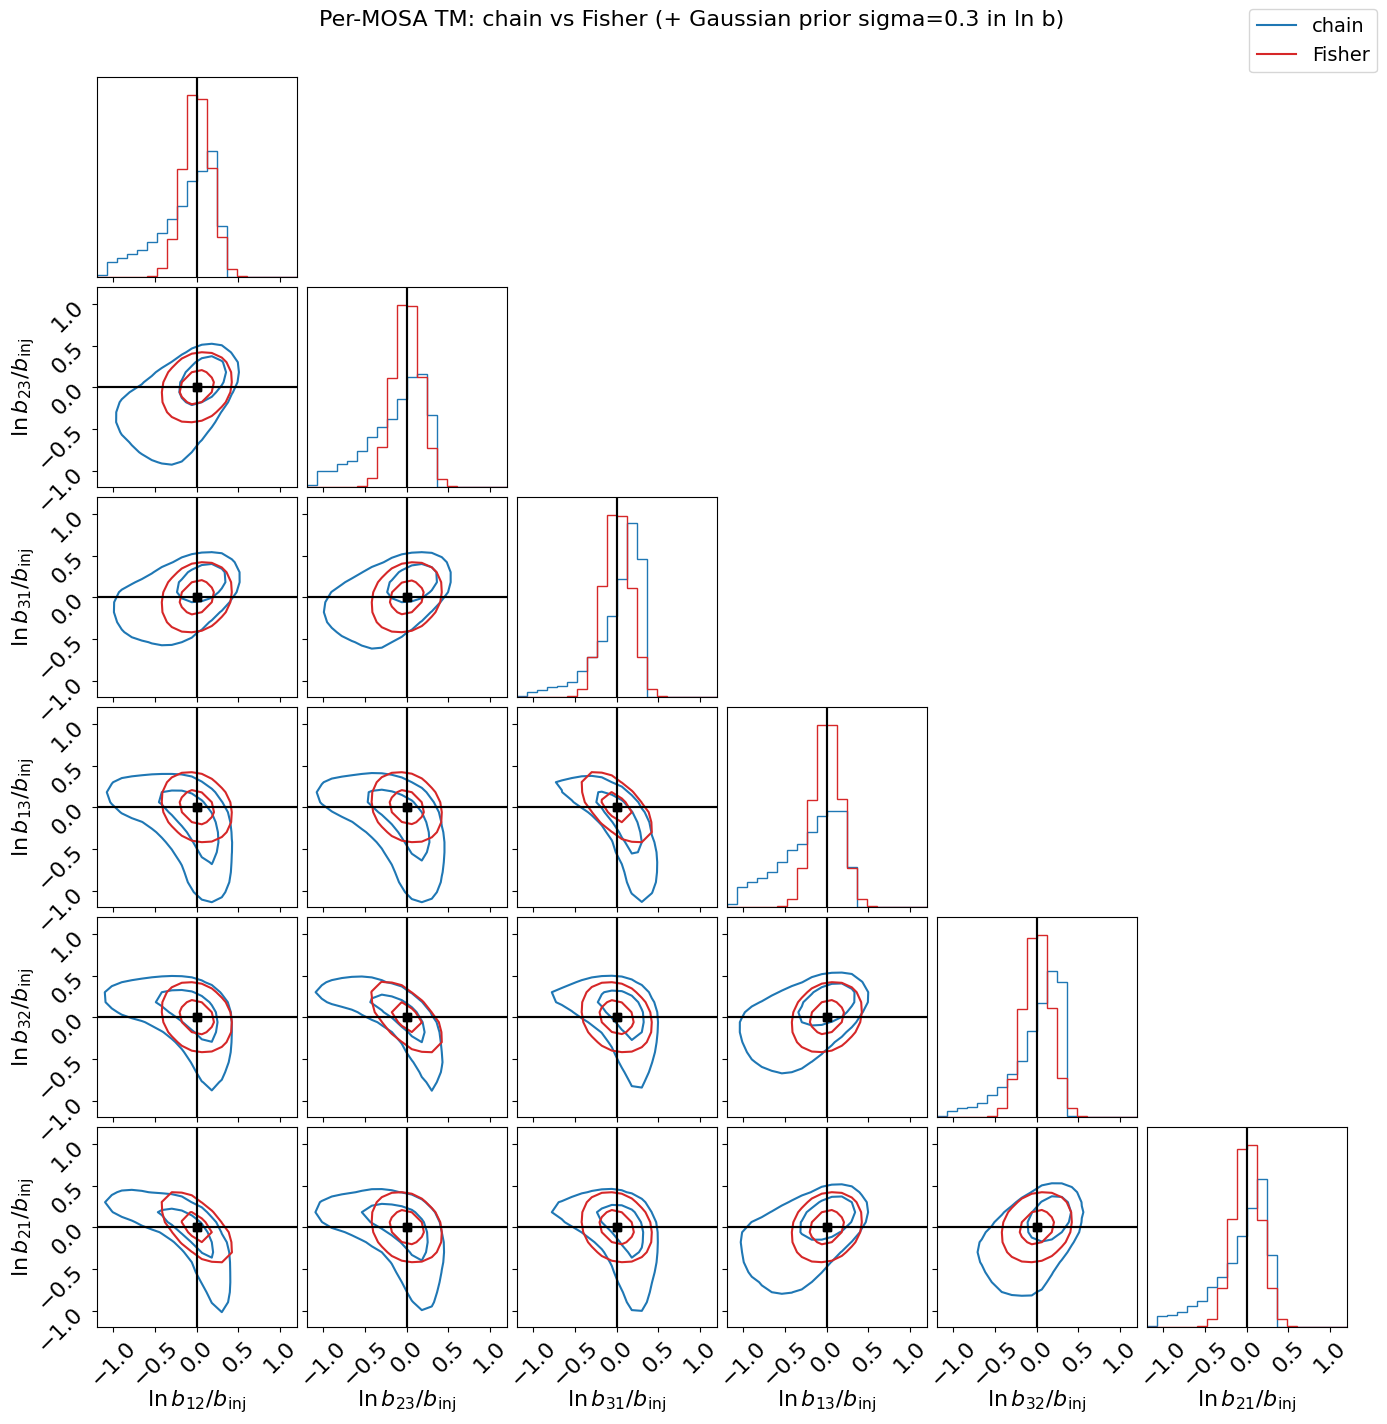

In [6]:
with h5py.File(CHAIN, "r") as fh:
    g = fh["global_fit"] if "global_fit" in fh else fh["mcmc"]
    it = int(g.attrs["iteration"])
    chain = g["chain/psd"][int(BURN_FRAC * it):it, 0, :, 0, :].reshape(-1, 12)
b = chain[:, 6:] / S_TM
P = b**2
lnA = np.column_stack([0.5 * np.log((P[:, i] + P[:, j]) / 2) for i, j in ARMS])
delta = np.column_stack([(P[:, i] - P[:, j]) / (P[:, i] + P[:, j]) for i, j in ARMS])
chain_mosa = np.log(b)
chain_proxy = np.column_stack([lnA, delta[:, 0] - delta[:, 1], delta[:, 1] - delta[:, 2]])
print("chain samples:", len(chain))

rng = np.random.default_rng(0)
N_FISHER = 40000
SIGMA_PRIOR = 0.3

def overlay(chain_x, cov, labels, title, ranges=None):
    fisher_x = rng.multivariate_normal(np.zeros(len(cov)), cov, size=N_FISHER)
    kw = dict(labels=labels, truths=np.zeros(len(cov)), plot_datapoints=False, plot_density=False,
              levels=(0.393, 0.865), smooth=1.0, range=ranges, truth_color="k")
    fig = corner.corner(chain_x, color="C0", hist_kwargs=dict(density=True), **kw)
    corner.corner(fisher_x, fig=fig, color="C3", hist_kwargs=dict(density=True), **kw)
    fig.legend(handles=[plt.Line2D([], [], color="C0", label="chain"),
                        plt.Line2D([], [], color="C3", label="Fisher")], loc="upper right", fontsize=14)
    fig.suptitle(title, y=1.02, fontsize=16)
    return fig

F_tm = marginalise(F, TM)
cov_mosa = np.linalg.inv(F_tm + np.eye(6) / SIGMA_PRIOR**2)
lim = 4 * SIGMA_PRIOR
overlay(chain_mosa, cov_mosa, [rf"$\ln b_{{{m}}}/b_{{\rm inj}}$" for m in MOSA_NAMES],
        f"Per-MOSA TM: chain vs Fisher (+ Gaussian prior sigma={SIGMA_PRIOR} in ln b)",
        ranges=[(-lim, lim)] * 6);

Fisher sigma: [0.022 0.022 0.022 0.479 0.479]
chain std:    [0.023 0.022 0.022 0.425 0.419]


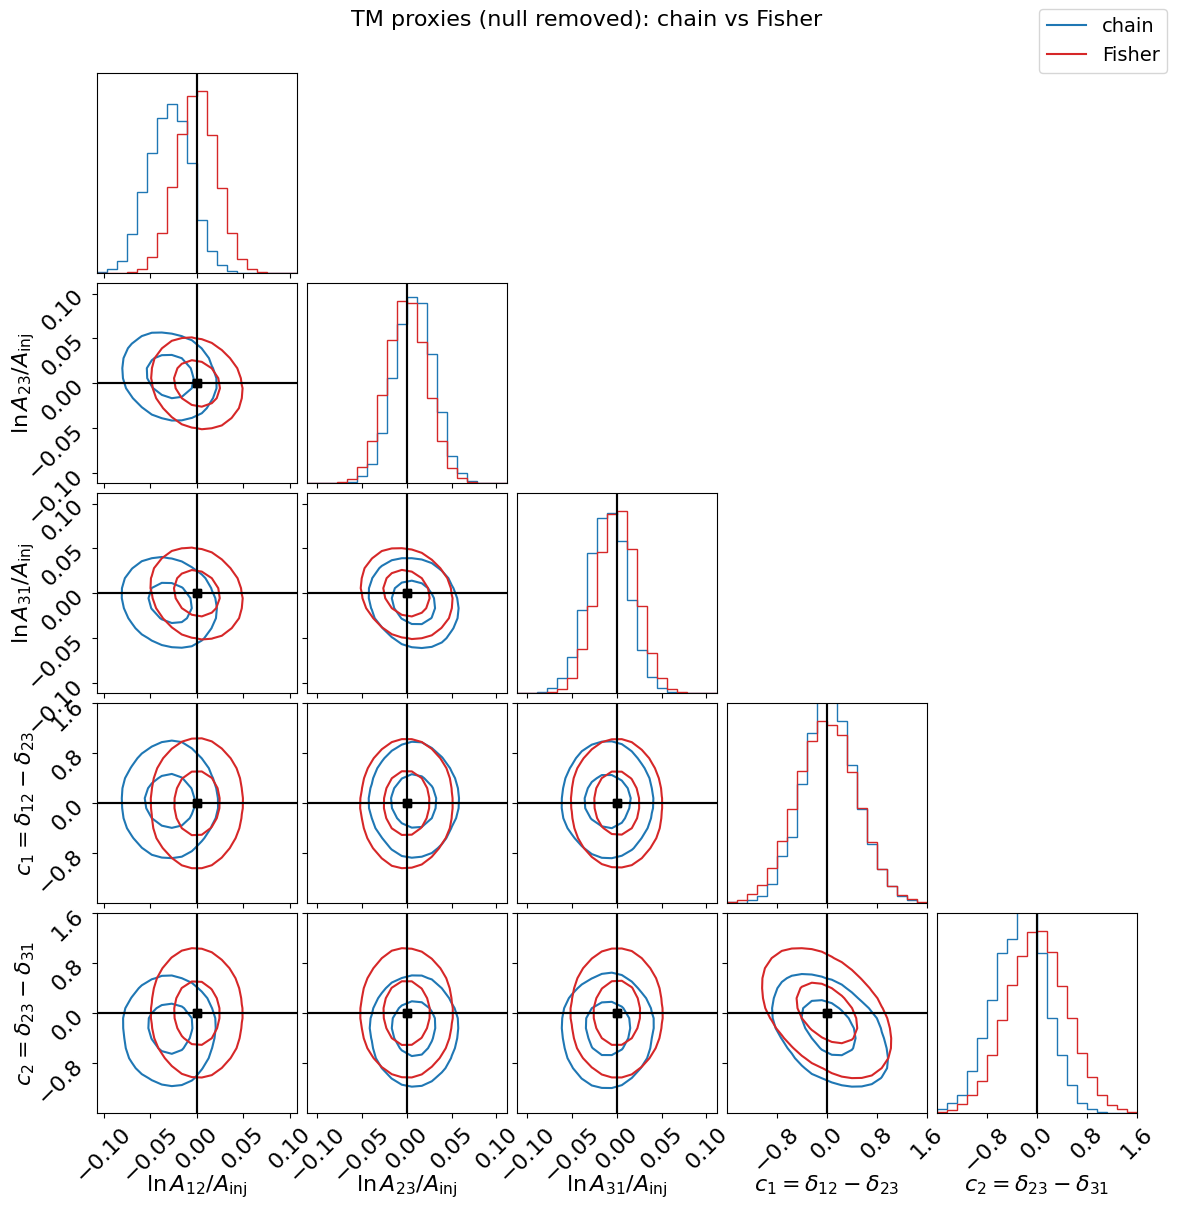

In [7]:
Fr, names_r = model_fisher("proxy-reduced")
cov_proxy = np.linalg.inv(marginalise(Fr, list(range(6, 11))))
s_proxy = np.sqrt(np.diag(cov_proxy))
overlay(chain_proxy, cov_proxy,
        [rf"$\ln A_{{{k}}}/A_{{\rm inj}}$" for k in TM_PROXY_ARMS] + [r"$c_1=\delta_{12}-\delta_{23}$", r"$c_2=\delta_{23}-\delta_{31}$"],
        "TM proxies (null removed): chain vs Fisher",
        ranges=[(-5 * s, 5 * s) for s in s_proxy[:3]] + [(-1.6, 1.6)] * 2);
print("Fisher sigma:", s_proxy)
print("chain std:   ", chain_proxy.std(0))

The contrasts $c_{1,2}$ are bounded by $|\delta_k| < 1$, so their chain marginals are truncated where the Fisher
Gaussian is not; the arm ASDs should agree in width and shape.

## 6. Correlation matrices

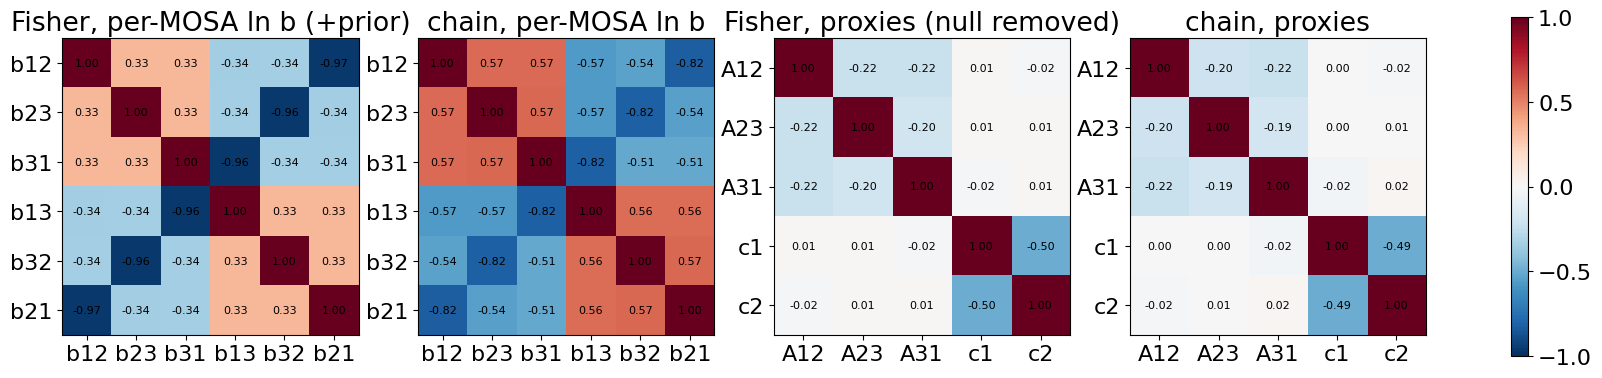

In [8]:
def corr(cov):
    s = np.sqrt(np.diag(cov))
    return cov / np.outer(s, s)

panels = [
    ("Fisher, per-MOSA ln b (+prior)", corr(cov_mosa), [f"b{m}" for m in MOSA_NAMES]),
    ("chain, per-MOSA ln b", np.corrcoef(chain_mosa.T), [f"b{m}" for m in MOSA_NAMES]),
    ("Fisher, proxies (null removed)", corr(cov_proxy), [f"A{k}" for k in TM_PROXY_ARMS] + ["c1", "c2"]),
    ("chain, proxies", np.corrcoef(chain_proxy.T), [f"A{k}" for k in TM_PROXY_ARMS] + ["c1", "c2"]),
]
fig, axes = plt.subplots(1, 4, figsize=(22, 5.5))
for ax, (title, R, lab) in zip(axes, panels):
    im = ax.imshow(R, vmin=-1, vmax=1, cmap="RdBu_r")
    ax.set_xticks(range(len(lab)), lab); ax.set_yticks(range(len(lab)), lab)
    for (i, j), v in np.ndenumerate(R):
        ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=8)
    ax.set_title(title)
fig.colorbar(im, ax=axes, shrink=0.8)